Цель: изучить применение модели логистической регрессии и метода опорных векторов в задаче бинарной классификации.

Описание задания:
В домашнем задании нужно решить задачу классификации физических лиц по уровню дохода.

Задачу классификации нужно решить при помощи модели логистической регрессии и модели опорных векторов.

от преподавателя: С первичным анализом данных всё отлично, еще можно было бы посмотреть на статистики основные
С визуальным анализом тоже всё хорошо. Отлично, что пишите выводы
Отлично, что признаки перевели через get_dummies. А признак income через LabelEncoder
С моделями тоже замечательно, только еще можно было бы поэкспериментировать с ядрами

- Получите данные и загрузите их в рабочую среду.
- Проведите первичный анализ.
- Проверьте данные на пропуски. Удалите в случае обнаружения. *Предложите альтернативный способ работы с пропусками
- Постройте 1-2 графика на выбор. Визуализация должна быть основана на исследуемых данных и быть полезной (из графика можно сделать вывод об особенностях датасета/класса/признака)
- Преобразуйте категориальные признаки.
- Разделите выборку на обучающее и тестовое подмножество. 80% данных оставить на обучающее множество, 20% на тестовое.
- Обучите модели логистической регрессии и опорных векторов на обучающем множестве.
- Для тестового множества предскажите уровень дохода и сравните с истинным значением, посчитав точность предсказания моделей. Для этого используйте встроенную функцию score.
- Сформулируйте выводы по проделанной работе.
- Кратко опишите какие преобразования были сделаны с данными.
- Сравните точность двух моделей.
Напишите свое мнение, в полной ли мере модели справились с поставленной задачей. *Что по вашему мнению нужно сделать, чтобы улучшить результат?

In [ ]:
import numpy as np
import pandas as pd
import scipy.stats
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

описание датасета https://www.cs.toronto.edu/~delve/data/adult/adultDetail.html

In [ ]:
data = pd.read_csv('adult.csv')
data.head(3)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [ ]:
data.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,0
relationship,0
race,0
gender,0


In [ ]:
data.workclass.unique()

array(['Private', 'Local-gov', '?', 'Self-emp-not-inc', 'Federal-gov',
       'State-gov', 'Self-emp-inc', 'Without-pay', 'Never-worked'],
      dtype=object)

In [ ]:
data = data.replace('?', np.nan)

In [ ]:
data.workclass.unique()

array(['Private', 'Local-gov', nan, 'Self-emp-not-inc', 'Federal-gov',
       'State-gov', 'Self-emp-inc', 'Without-pay', 'Never-worked'],
      dtype=object)

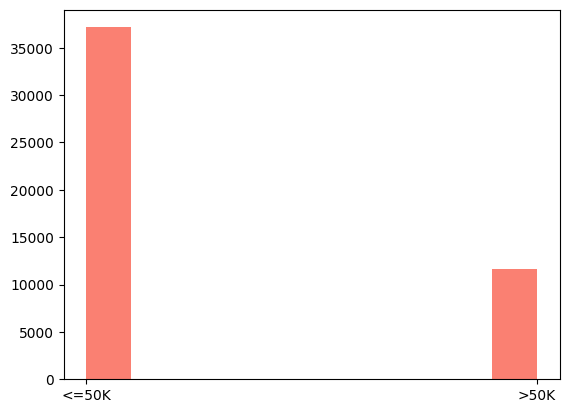

In [ ]:
plt.hist(data.income, color='salmon')
plt.show()

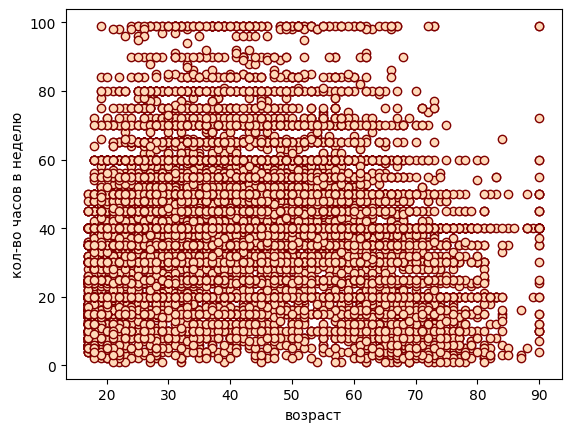

In [ ]:
plt.scatter(data.age, data['hours-per-week'], edgecolors='maroon', color='peachpuff')
plt.xlabel('возраст')
plt.ylabel('кол-во часов в неделю')
plt.show()

tight_layout автоматически настраивает параметры подграфика так, чтобы подграфик(и) вписывались в область рисунка. Альтернатива - constrained_layout.

<Figure size 640x480 with 0 Axes>

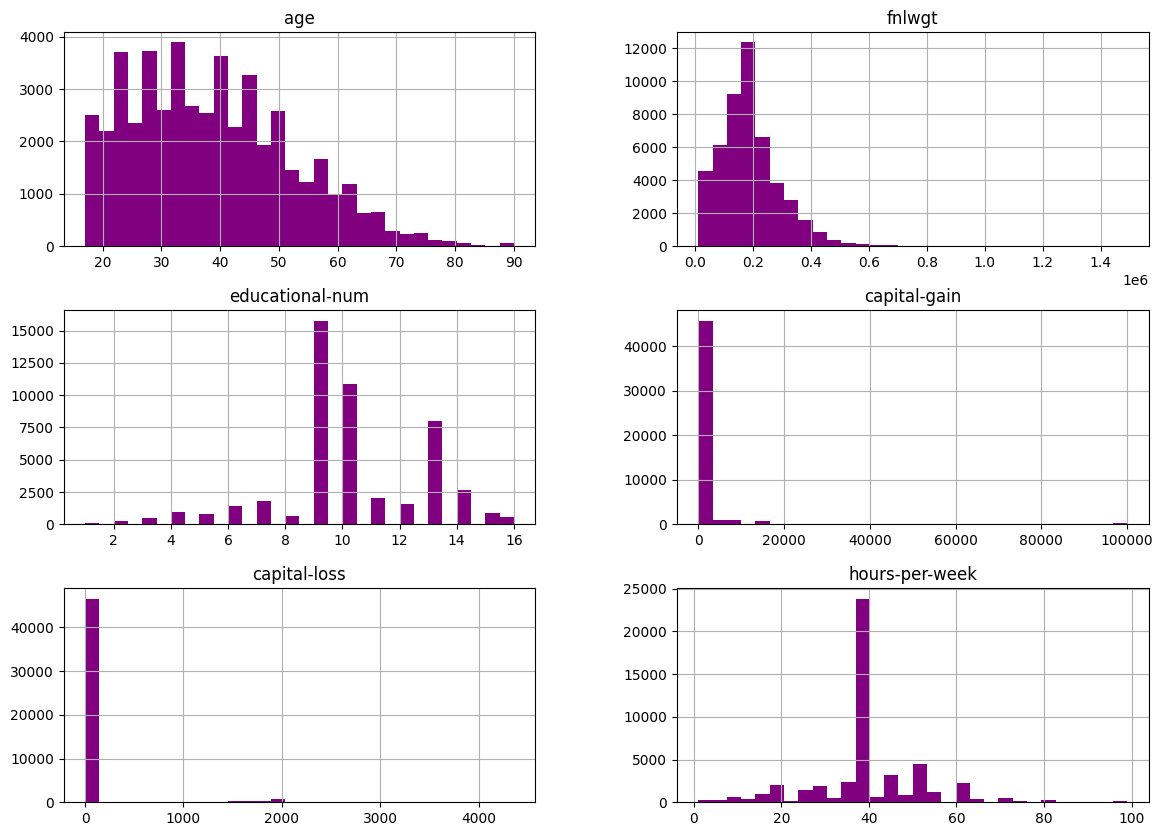

In [ ]:
plt.tight_layout()
data.hist(bins = 30, color='purple', figsize = (14, 10))
plt.show()

# График получился только по числовым показателям, это понятно.
# можем посметреть по возрасту: основной возраст в пределах 20 - 45 или
# большинство работают 40 часов в неделю - видим нормальное распределение.

In [ ]:
data.sample(3)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
43301,67,Private,174693,Some-college,10,Widowed,Sales,Not-in-family,White,Female,0,0,25,Nicaragua,<=50K
23390,34,Private,175878,HS-grad,9,Married-civ-spouse,Sales,Husband,White,Female,0,0,40,United-States,<=50K
19582,53,Private,200576,11th,7,Divorced,Craft-repair,Other-relative,White,Female,0,0,40,United-States,<=50K


In [ ]:
label = LabelEncoder()

In [ ]:
data['gender'] = label.fit_transform(data['gender'])

In [ ]:
y = pd.Series(data=label.fit_transform(data['income']))

In [ ]:
y.head(2)

,0
0,0
1,0


In [ ]:
x = pd.get_dummies(data.loc[:, ['gender', 'age', 'educational-num', 'capital-gain',	'capital-loss',	'hours-per-week', 'occupation']])
x.head()

,gender,age,educational-num,capital-gain,capital-loss,hours-per-week,occupation_Adm-clerical,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving
0,1,25,7,0,0,40,False,False,False,False,False,False,True,False,False,False,False,False,False,False
1,1,38,9,0,0,50,False,False,False,False,True,False,False,False,False,False,False,False,False,False
2,1,28,12,0,0,40,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,1,44,10,7688,0,40,False,False,False,False,False,False,True,False,False,False,False,False,False,False
4,0,18,10,0,0,30,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.2, random_state=0)

In [ ]:
x_train.shape, x_test.shape

((39073, 20), (9769, 20))

In [ ]:
#scaler = StandardScaler().fit(x_train)

In [ ]:
#x_train = scaler.transform(x_train)    max_iter=5000

In [ ]:
model = LogisticRegression(max_iter=10000)
model.fit(x_train, y_train)

LogisticRegression(max_iter=10000)

In [ ]:
model_svc = SVC()
model_svc.fit(x_train, y_train)

SVC()

In [ ]:
model.score(x_train, y_train), model.score(x_test,y_test)

(0.8305735418319555, 0.8251612242808886)

In [ ]:
model_svc.score(x_train, y_train), model_svc.score(x_test,y_test)

(0.803035344099506, 0.8007984440577336)

In [ ]:
y_pred = model.predict_proba(x_test)
y_pred[:3]

array([[0.60047495, 0.39952505],
       [0.30073749, 0.69926251],
       [0.14228664, 0.85771336]])

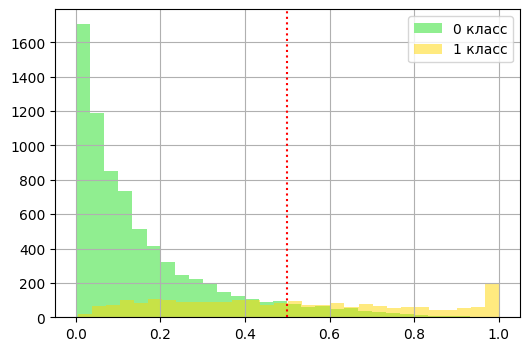

In [ ]:
plt.figure(figsize=(6,4))
x_ = plt.hist(y_pred[y_test==0][:,1], bins=30, color='lightgreen', label='0 класс')
x_ = plt.hist(y_pred[y_test==1][:,1], bins=30, color='gold', alpha=0.5, label='1 класс')
plt.axvline(0.5, color='r', linestyle=':')
plt.grid()
plt.legend()
plt.show()
# распределения для 2 классов
# есть смешение классов и, мне кажется, оно всё-таки большое и это не очень хорошо.
# Наверное, надо дальше работать с функцией потерь, чтобы уменьшить ошибки

In [ ]:
model_kernel = SVC(kernel='poly', degree=3)
model_kernel.fit(x_train, y_train)

SVC(kernel='poly')

In [ ]:
model_kernel.score(x_train, y_train), model_kernel.score(x_test, y_test)

(0.7858111739564405, 0.7848295629030607)